In [32]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn. datasets import make_moons 
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
import tensorflow 
from tensorflow. keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [33]:
x, y = make_moons(100, noise=0.25, random_state=2)

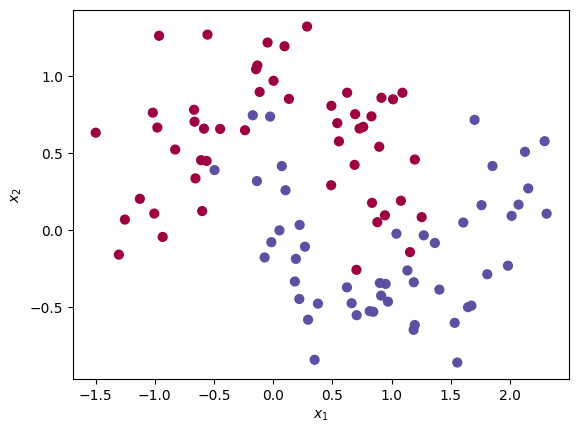

In [34]:
plt.figure()
plt.scatter(x[:,0], x[:,1], c=y, cmap=plt.cm.Spectral, s=40)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()


In [35]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)

model = Sequential()
model.add(Dense(128, input_dim=2, activation='relu'))

model.add(Dense(128, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(0.01)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['mse'])   

In [37]:
history = model.fit(x_train, y_train, epochs=2000, validation_data=(x_test, y_test))

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - loss: 0.6128 - mse: 0.2113 - val_loss: 0.3002 - val_mse: 0.0764
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.4469 - mse: 0.1448 - val_loss: 0.1433 - val_mse: 0.0284
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.4214 - mse: 0.1360 - val_loss: 0.1210 - val_mse: 0.0210
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.4087 - mse: 0.1349 - val_loss: 0.0990 - val_mse: 0.0151
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.4002 - mse: 0.1296 - val_loss: 0.1253 - val_mse: 0.0257
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.3825 - mse: 0.1215 - val_loss: 0.1348 - val_mse: 0.0252
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.3536 - mse: 0.1122 - val_loss: 0.1483 - val_mse: 0.0284
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.3467 - mse: 0.1087 - val_loss: 0.1529 - val_mse: 0.0312
Epoch 9/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.32

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


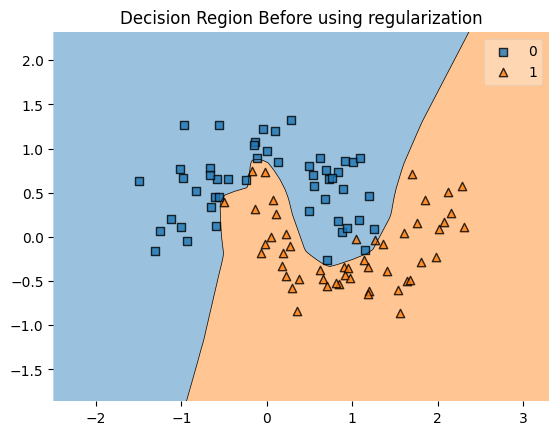

In [ ]:
plt.title('Decision Region Before using regularization')
plot_decision_regions(x, y, model)
plt.show()


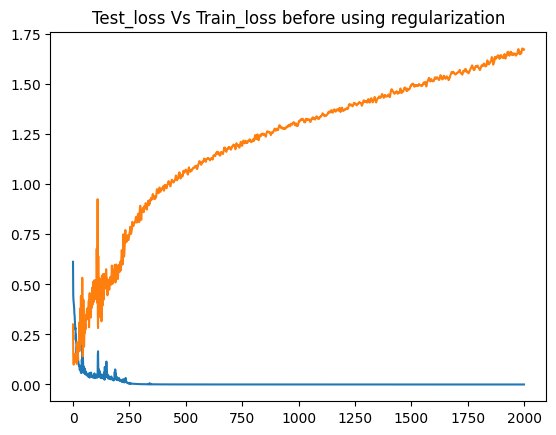

In [52]:
plt.figure()
plt.title('Test_loss Vs Train_loss before using regularization')
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.show()



In [40]:
from tensorflow.keras.regularizers import l2
model1 = Sequential()
model1.add(Dense(128, input_dim=2, activation='relu', kernel_regularizer=l2(0.03)))

model1.add(Dense(128, activation='relu', kernel_regularizer=l2(0.03)))

model1.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
optimizer1 = Adam(0.01)

In [46]:
model1.compile(loss='binary_crossentropy',optimizer = optimizer1, metrics = ['mse'])

In [47]:
history1 = model1.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=2000)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - loss: 4.0904 - mse: 0.2399 - val_loss: 2.6820 - val_mse: 0.1748
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 2.3870 - mse: 0.1938 - val_loss: 1.4857 - val_mse: 0.1278
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 1.3919 - mse: 0.1700 - val_loss: 0.8469 - val_mse: 0.0974
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.8813 - mse: 0.1509 - val_loss: 0.5582 - val_mse: 0.0729
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.6841 - mse: 0.1408 - val_loss: 0.4604 - val_mse: 0.0558
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.6517 - mse: 0.1379 - val_loss: 0.4422 - val_mse: 0.0453
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.6626 - mse: 0.1380 - val_loss: 0.4653 - val_mse: 0.0506
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.6729 - mse: 0.1426 - val_loss: 0.4409 - val_mse: 0.0469
Epoch 9/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.62

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


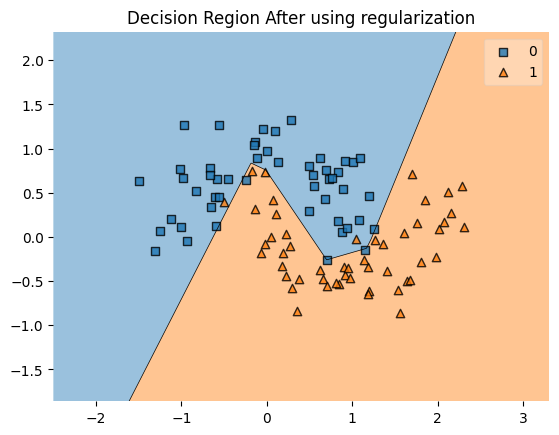

In [ ]:
plot_decision_regions(x, y, model1)
plt.title('Decision Region After using regularization')
plt.show()

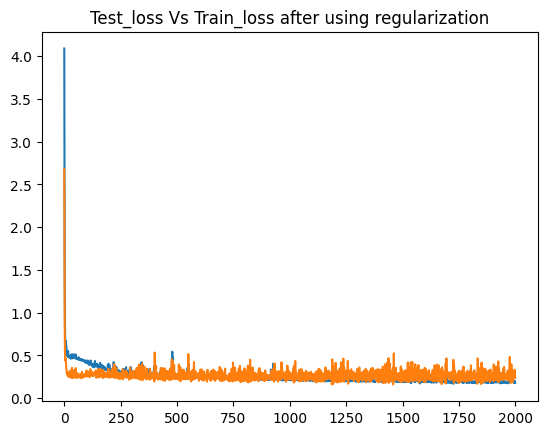

In [50]:
plt.figure()
plt.title('Test_loss Vs Train_loss after using regularization')
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.show()


In [74]:
W_beforeregu = model.get_weights()[0].reshape(256)
W_afterregu = model1.get_weights()[0].reshape(256)

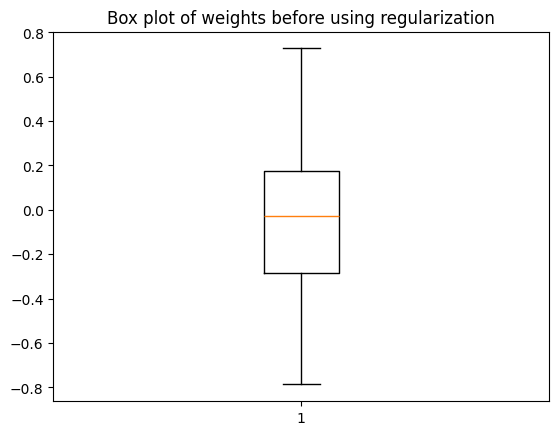

In [78]:
plt.figure()
plt.title('Box plot of weights before using regularization')
plt.boxplot(W_beforeregu)
plt.show()


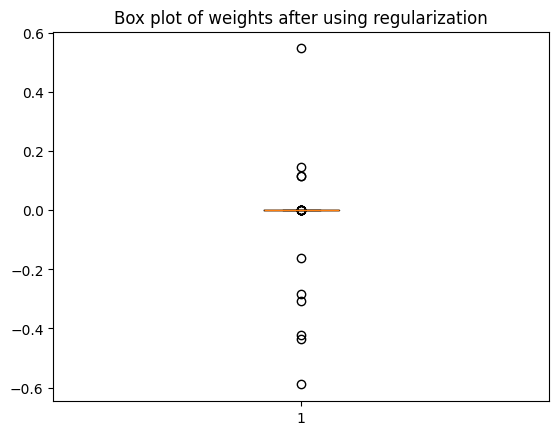

In [79]:
plt.figure()
plt.title('Box plot of weights after using regularization')
plt.boxplot(W_afterregu)
plt.show()